# vbOCP — Sweep iperparametri PODNN (stato/aggiunto)

Notebook orchestratore bash-style: le celle lanciano solo comandi verso `src/rom/sweep_pod_nn.py`. Richiede che gli snapshot di training/test e la mesh siano gia' pronti (vedi `run_pipeline.ipynb`, sezioni 1-2).

## 1. Setup

In [1]:
import os

while not os.path.isdir('src') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
assert os.path.isdir('src'), "src/ non trovata: verifica dove e' montata la repo vbOCP"

REPO_ROOT           = os.getcwd()
CONFIG_PATH         = os.path.join('configs', 'test1.yaml')
SNAPSHOTS_DIR        = os.path.join('data', 'snapshots')
SNAPSHOTS_PATH       = os.path.join(SNAPSHOTS_DIR, 'test1_300.npz')
TEST_SNAPSHOTS_PATH  = os.path.join(SNAPSHOTS_DIR, 'test1_test150.npz')

os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

print('REPO_ROOT          :', REPO_ROOT)
print('SNAPSHOTS_PATH      :', SNAPSHOTS_PATH)
print('TEST_SNAPSHOTS_PATH :', TEST_SNAPSHOTS_PATH)

REPO_ROOT          : /shared/vbOCP
SNAPSHOTS_PATH      : data/snapshots/test1_300.npz
TEST_SNAPSHOTS_PATH : data/snapshots/test1_test150.npz


## 2. Sweep sul numero di modi (hidden_dim fisso)

Mesh/snapshot vengono caricati una sola volta dentro lo script (non ad ogni punto). Con epoche piene e molti valori, richiede parecchio tempo.

In [14]:
N_MODES_VALUES = '10,20,30,40,50,60,80'
HIDDEN_DIM = 32
EPOCHS = 50000
SWEEP_N_MODES_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_n_modes.csv')

!python -m src.rom.sweep_pod_nn \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --sweep-param n_modes \
    --values {N_MODES_VALUES} \
    --hidden-dim {HIDDEN_DIM} \
    --epochs {EPOCHS} \
    --output {SWEEP_N_MODES_OUTPUT}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300.npz ...
^C
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/shared/vbOCP/src/rom/sweep_pod_nn.py", line 170, in <module>
    main()
    ~~~~^^
  File "/shared/vbOCP/src/rom/sweep_pod_nn.py", line 118, in main
    Y, P = data["Y"], data["P"]
           ~~~~^^^^^
  File "/usr/local/lib/python3.13/dist-packages/numpy/lib/_npyio_impl.py", line 257, in __getitem__
    return format.read_array(
           ~~~~~~~~~~~~~~~~~^
        bytes,
        ^^^^^^
    ...<2 lines>...
        max_header_size=self.max_header_size
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/numpy/lib/_format_impl.py", line 869, in read_array
    data = _read_bytes(fp, read_size, "array data")
  File "/usr/local/lib/python3.13/dist-packages/numpy/l

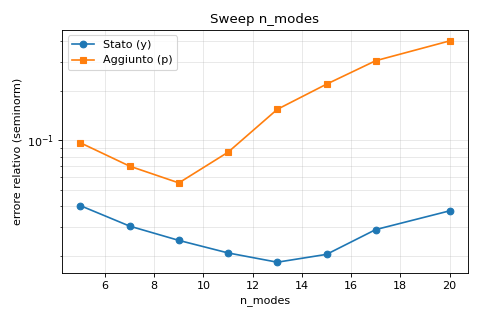

In [14]:
from pathlib import Path
from IPython.display import Image
Image(str(Path(SWEEP_N_MODES_OUTPUT).with_suffix('.png')))

In [15]:
import csv

with open(SWEEP_N_MODES_OUTPUT) as f:
    for row in csv.DictReader(f):
        print(row)

{'n_modes': '5', 'err_y': '0.040299794948854', 'err_p': '0.09681430144396622'}
{'n_modes': '7', 'err_y': '0.030307168563962417', 'err_p': '0.06993394173933204'}
{'n_modes': '9', 'err_y': '0.024838431205772005', 'err_p': '0.05536615132062824'}
{'n_modes': '11', 'err_y': '0.0208518720419052', 'err_p': '0.08495564713535302'}
{'n_modes': '13', 'err_y': '0.018325911135815796', 'err_p': '0.1544122397418849'}
{'n_modes': '15', 'err_y': '0.020439781423214586', 'err_p': '0.21927907084205397'}
{'n_modes': '17', 'err_y': '0.028876082461930727', 'err_p': '0.3042006404273881'}
{'n_modes': '20', 'err_y': '0.037486449829311444', 'err_p': '0.40074951457932284'}


### 2.1 Solo POD (nessuna rete) - limite inferiore dell'errore

Errore di proiezione di Galerkin sul test set, stessa griglia di N di sopra. Molto piu' veloce (nessun training) - utile per verificare che l'errore della PODNN sia sempre >= di questo (la POD e' il limite migliore possibile con N modi).

In [15]:
SWEEP_POD_ERROR_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_pod_error.csv')
from IPython.display import Image
!python -m src.rom.sweep_pod_error \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --values {N_MODES_VALUES} \
    --output {SWEEP_POD_ERROR_OUTPUT}

Image(str(Path(SWEEP_POD_ERROR_OUTPUT).with_suffix('.png')))

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300.npz ...
Caricamento test set da data/snapshots/test1_test150.npz ...
N=10  err_y_pod=2.2409e-02  err_p_pod=1.5958e-02
N=20  err_y_pod=1.0396e-02  err_p_pod=1.7717e-03
N=30  err_y_pod=6.6408e-03  err_p_pod=5.3718e-04
N=40  err_y_pod=4.5695e-03  err_p_pod=2.0141e-04
N=50  err_y_pod=3.1280e-03  err_p_pod=8.8686e-05
N=60  err_y_pod=2.4663e-03  err_p_pod=4.7396e-05
N=80  err_y_pod=1.3416e-03  err_p_pod=1.7268e-05

Risultati salvati in data/snapshots/sweep_pod_error.csv
Plot salvato in data/snapshots/sweep_pod_error.png


NameError: name 'Path' is not defined

### 2.2 Confronto POD vs PODNN (stesso grafico)

Sovrappone le due curve gia' calcolate sopra (nessun nuovo run - solo lettura dei CSV): errore di sola POD (limite inferiore) vs errore PODNN (POD + rete), un subplot per stato e uno per aggiunto.

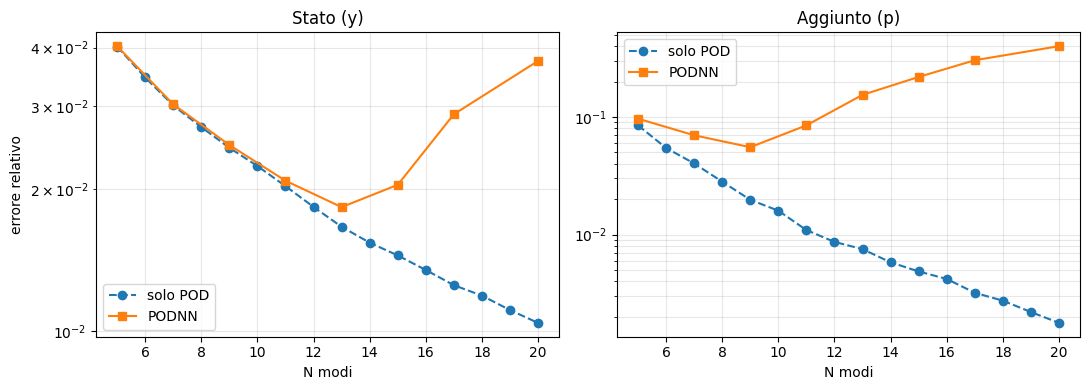

In [16]:
import csv
import matplotlib.pyplot as plt

def read_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))

podnn_rows = read_csv(SWEEP_N_MODES_OUTPUT)
pod_rows = read_csv(SWEEP_POD_ERROR_OUTPUT)

n_podnn = [int(r['n_modes']) for r in podnn_rows]
n_pod = [int(r['n_modes']) for r in pod_rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

axes[0].semilogy(n_pod, [float(r['err_y_pod']) for r in pod_rows], 'o--', label='solo POD')
axes[0].semilogy(n_podnn, [float(r['err_y']) for r in podnn_rows], 's-', label='PODNN')
axes[0].set_title('Stato (y)')
axes[0].set_xlabel('N modi')
axes[0].set_ylabel('errore relativo')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(n_pod, [float(r['err_p_pod']) for r in pod_rows], 'o--', label='solo POD')
axes[1].semilogy(n_podnn, [float(r['err_p']) for r in podnn_rows], 's-', label='PODNN')
axes[1].set_title('Aggiunto (p)')
axes[1].set_xlabel('N modi')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Training set continuo vs allineato alla mesh

`test1_300.npz` e' stato generato con `--align-mu-u-to-mesh`: solo 121 valori distinti di
mu_u su 300 campioni (molti ripetuti). Il test set invece ha mu_u continuo (150 valori
tutti distinti, mai visti in training) - possibile causa del gap PODNN vs solo-POD,
specialmente per l'aggiunto p. Qui generiamo un training set della stessa dimensione ma
con mu_u campionato in modo continuo (come il test set), e confrontiamo l'errore PODNN
tra i due, a parita' di N e iperparametri.

In [2]:
CONTINUOUS_SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_300_continuous.npz')

!python -m src.full_order.generate_snapshots \
    --config {CONFIG_PATH} \
    --n-samples 300 \
    --seed 42 \
    --output {CONTINUOUS_SNAPSHOTS_PATH}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Nh = 5306
Assembly operatori (indipendenti da mu) ...
  300/300  elapsed=13.5s  avg=0.05s/snapshot
Snapshot salvati in data/snapshots/test1_300_continuous.npz


In [ ]:
SWEEP_N_MODES_CONTINUOUS_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_n_modes_continuous.csv')

!python -m src.rom.sweep_pod_nn \
    --config {CONFIG_PATH} \
    --snapshots {CONTINUOUS_SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --sweep-param n_modes \
    --values {N_MODES_VALUES} \
    --hidden-dim {HIDDEN_DIM} \
    --epochs {100000} \
    --output {SWEEP_N_MODES_CONTINUOUS_OUTPUT}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300_continuous.npz ...
Caricamento test set da data/snapshots/test1_test150.npz ...

=== [1/8] n_modes = 5 ===


In [16]:
SWEEP_POD_ERROR_CONTINUOUS_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_pod_error_continuous.csv')

!python -m src.rom.sweep_pod_error \
    --config {CONFIG_PATH} \
    --snapshots {CONTINUOUS_SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --values {N_MODES_VALUES} \
    --output {SWEEP_POD_ERROR_CONTINUOUS_OUTPUT}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300_continuous.npz ...
Caricamento test set da data/snapshots/test1_test150.npz ...
N=10  err_y_pod=2.1009e-02  err_p_pod=1.4541e-02
N=20  err_y_pod=9.4400e-03  err_p_pod=1.6182e-03
N=30  err_y_pod=6.1068e-03  err_p_pod=4.6257e-04
N=40  err_y_pod=4.1368e-03  err_p_pod=1.6691e-04
N=50  err_y_pod=3.0850e-03  err_p_pod=7.6549e-05
N=60  err_y_pod=2.2805e-03  err_p_pod=4.0507e-05
N=80  err_y_pod=1.2832e-03  err_p_pod=1.4262e-05

Risultati salvati in data/snapshots/sweep_pod_error_continuous.csv
Plot salvato in data/snapshots/sweep_pod_error_continuous.png


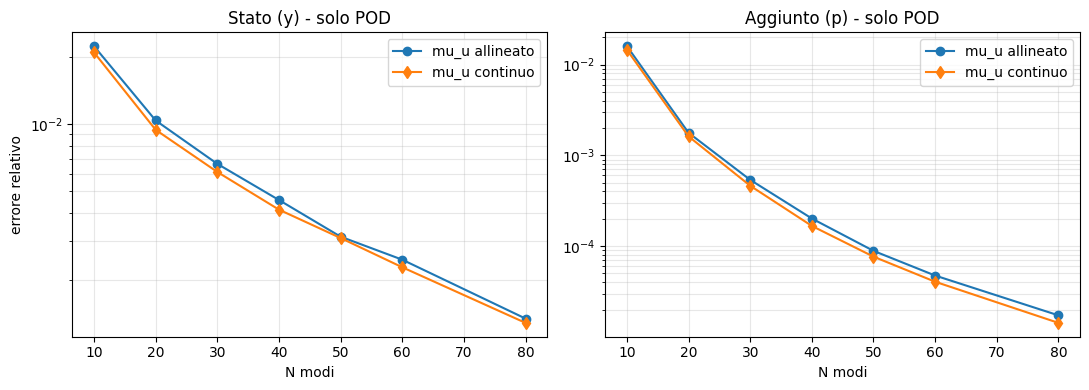

In [17]:
import csv
import matplotlib.pyplot as plt

def read_csv(path):
    with open(path) as f:
        return list(csv.DictReader(f))

pod_rows = read_csv(SWEEP_POD_ERROR_OUTPUT)
pod_cont_rows = read_csv(SWEEP_POD_ERROR_CONTINUOUS_OUTPUT)
n_pod = [int(r['n_modes']) for r in pod_rows]
n_pod_cont = [int(r['n_modes']) for r in pod_cont_rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

axes[0].semilogy(n_pod, [float(r['err_y_pod']) for r in pod_rows], 'o-', label='mu_u allineato')
axes[0].semilogy(n_pod_cont, [float(r['err_y_pod']) for r in pod_cont_rows], 'd-', label='mu_u continuo')
axes[0].set_title('Stato (y) - solo POD')
axes[0].set_xlabel('N modi')
axes[0].set_ylabel('errore relativo')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(n_pod, [float(r['err_p_pod']) for r in pod_rows], 'o-', label='mu_u allineato')
axes[1].semilogy(n_pod_cont, [float(r['err_p_pod']) for r in pod_cont_rows], 'd-', label='mu_u continuo')
axes[1].set_title('Aggiunto (p) - solo POD')
axes[1].set_xlabel('N modi')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
podnn_cont_rows = read_csv(SWEEP_N_MODES_CONTINUOUS_OUTPUT)
pod_cont_rows = read_csv(SWEEP_POD_ERROR_CONTINUOUS_OUTPUT)
n_cont = [int(r['n_modes']) for r in podnn_cont_rows]
n_pod_cont = [int(r['n_modes']) for r in pod_cont_rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

axes[0].semilogy(n_pod, [float(r['err_y_pod']) for r in pod_rows], 'o--', label='solo POD (mu_u allineato)')
axes[0].semilogy(n_pod_cont, [float(r['err_y_pod']) for r in pod_cont_rows], 'd--', label='solo POD (mu_u continuo)')
axes[0].semilogy(n_podnn, [float(r['err_y']) for r in podnn_rows], 's-', label='PODNN (mu_u allineato)')
axes[0].semilogy(n_cont, [float(r['err_y']) for r in podnn_cont_rows], '^-', label='PODNN (mu_u continuo)')
axes[0].set_title('Stato (y)')
axes[0].set_xlabel('N modi')
axes[0].set_ylabel('errore relativo')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogy(n_pod, [float(r['err_p_pod']) for r in pod_rows], 'o--', label='solo POD (mu_u allineato)')
axes[1].semilogy(n_pod_cont, [float(r['err_p_pod']) for r in pod_cont_rows], 'd--', label='solo POD (mu_u continuo)')
axes[1].semilogy(n_podnn, [float(r['err_p']) for r in podnn_rows], 's-', label='PODNN (mu_u allineato)')
axes[1].semilogy(n_cont, [float(r['err_p']) for r in podnn_cont_rows], '^-', label='PODNN (mu_u continuo)')
axes[1].set_title('Aggiunto (p)')
axes[1].set_xlabel('N modi')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Sweep su hidden_dim (N fisso)

*(da lanciare dopo aver scelto N dal risultato dello sweep sopra)*

In [8]:
HIDDEN_DIM_VALUES = '16,32,64,128'
N_MODES_FIXED = 14  # aggiorna con il valore migliore trovato nello sweep precedente
SWEEP_HIDDEN_DIM_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_hidden_dim.csv')

!python -m src.rom.sweep_pod_nn \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --sweep-param hidden_dim \
    --values {HIDDEN_DIM_VALUES} \
    --n-modes {N_MODES_FIXED} \
    --epochs {EPOCHS} \
    --output {SWEEP_HIDDEN_DIM_OUTPUT}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300.npz ...
Caricamento test set da data/snapshots/test1_test150.npz ...

=== [1/4] hidden_dim = 16 ===
  err_y=2.0125e-02  err_p=4.9338e-01  (71.8s)

=== [2/4] hidden_dim = 32 ===
  err_y=1.7826e-02  err_p=1.7048e-01  (87.6s)

=== [3/4] hidden_dim = 64 ===
  err_y=2.1390e-02  err_p=1.9284e-01  (93.4s)

=== [4/4] hidden_dim = 128 ===
  err_y=2.0545e-02  err_p=1.4246e-01  (26.9s)

Risultati salvati in data/snapshots/sweep_hidden_dim.csv
Plot salvato in data/snapshots/sweep_hidden_dim.png


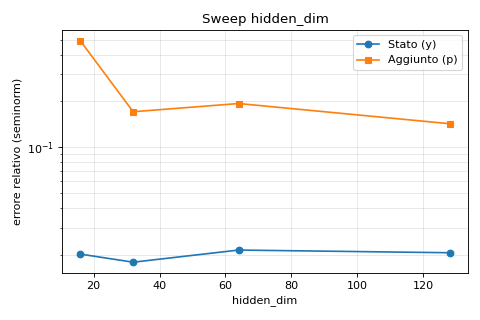

In [9]:
Image(str(Path(SWEEP_HIDDEN_DIM_OUTPUT).with_suffix('.png')))